# 01 · Data Cleaning: NYC Yellow Taxi Trip Data
**Owner:** Member 1 (Data Lead) · **Output:** `data/processed/yellow_taxi_clean.parquet`, `figures/cleaning_*.png`, `data/processed/cleaning_summary.json`

**Pipeline**
1. Load every CSV in `data/raw/` (cuDF on GPU if RAPIDS is installed, otherwise pandas)
2. Audit: size, dtypes, missing values, summary statistics
3. Remove exact duplicates
4. Apply documented validity rules one at a time (a "row funnel" so every removal is explained)
5. Engineer a few transformation columns used later in EDA
6. Validate that the clean data breaks no rule, then save
7. Before/after figures for the presentation

> Design choice: **hard, domain-based rules** (a taxi cannot travel 500 miles in 2 minutes) rather than statistical trimming, so every removal is easy to justify in the presentation. Skewed-but-valid values such as long airport trips are **kept**, and Members 2 and 3 can use log scales in EDA.

## 1. Setup and configuration

In [1]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
T0 = time.time()

# ---- Backend: GPU (RAPIDS cuDF) if available, else CPU (pandas) ----
try:
    import cudf
    DF = cudf
    BACKEND = "cuDF (GPU, RAPIDS)"
except ImportError:
    DF = pd
    BACKEND = "pandas (CPU)"
print("Backend:", BACKEND)

# ---- Paths (works whether the notebook is run from /notebooks or from the repo root) ----
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR, PROC_DIR, FIG_DIR = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "figures"
for d in (PROC_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Settings ----
KEEP_FRACTION = 0.25          # random 25% of every file (about 11.8M rows). 1.0 = all ~47M rows, which does not fit in a free Colab GPU/RAM
MAX_ROWS_PER_FILE = None      # alternative for quick tests: first N rows only (biased to the start of the month)
SAMPLE_N = 200_000            # rows sampled for plots (the cleaning itself always uses all rows)
SEED = 42
NYC_LAT, NYC_LON = (40.45, 41.00), (-74.30, -73.65)      # generous bounding box around the 5 boroughs
VALID_START, VALID_END = pd.Timestamp("2015-01-01"), pd.Timestamp("2016-04-01")   # study period
MAX_DURATION_MIN, MAX_DISTANCE_MI, MAX_FARE, MAX_SPEED_MPH = 180, 100, 500, 80

BLUE, ORANGE, GREY, RED = "#0072B2", "#E69F00", "#9AA0A6", "#D55E00"   # colour-blind-safe palette
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11})

def to_pd(x):
    """Move a cuDF object to pandas for plotting; pass pandas through unchanged."""
    return x.to_pandas() if hasattr(x, "to_pandas") else x

Backend: pandas (CPU)


### Optional: download the data automatically
Skips itself if `data/raw/` already has CSV files. Needs `pip install kagglehub` (works on Colab). If it fails, download manually as described in `data/raw/README.md`.

In [2]:
if not list(RAW_DIR.glob("*.csv")):
    try:
        import shutil, kagglehub
        src = Path(kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data"))
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        for f in src.rglob("*.csv"):
            shutil.copy(f, RAW_DIR / f.name)
        print("Downloaded:", sorted(p.name for p in RAW_DIR.glob("*.csv")))
    except Exception as e:
        print("Auto-download failed:", e, "\nDownload manually: see data/raw/README.md")
else:
    print("Raw CSV files already present, skipping download.")

100%|██████████| 1.78G/1.78G [00:44<00:00, 42.8MB/s]

Extracting files...


Downloaded: ['yellow_tripdata_2015-01.csv', 'yellow_tripdata_2016-01.csv', 'yellow_tripdata_2016-02.csv', 'yellow_tripdata_2016-03.csv']


## 2. Load the raw data

In [3]:
files = sorted(RAW_DIR.glob("*.csv"))
assert files, f"No CSV files found in {RAW_DIR}. See data/raw/README.md for the download steps."

WANTED = ["VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance",
          "pickup_longitude", "pickup_latitude", "RatecodeID", "store_and_fwd_flag",
          "dropoff_longitude", "dropoff_latitude", "payment_type", "fare_amount", "extra", "mta_tax",
          "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount"]

import gc
frames, schema_notes, source_rows = [], [], {}
for f in files:
    header = list(pd.read_csv(f, nrows=0).columns)                  # peek at the header only
    # Match column names ignoring capitalisation (e.g. 2015 file says "RateCodeID", 2016 files say "RatecodeID")
    wanted_lc = {c.lower(): c for c in WANTED}
    rename = {h: wanted_lc[h.strip().lower()] for h in header if h.strip().lower() in wanted_lc}
    cols = list(rename.keys())
    missing_cols = [c for c in WANTED if c not in rename.values()]
    spelling = {h: c for h, c in rename.items() if h != c}
    if spelling:
        schema_notes.append(f"{f.name}: column names differ in capitalisation, harmonised {spelling}")
    if missing_cols:
        schema_notes.append(f"{f.name}: missing columns {missing_cols}")
    if KEEP_FRACTION < 1.0 and DF is pd:        # CPU: read in chunks, keep a random fraction (low RAM)
        n_src, parts = 0, []
        for ch in pd.read_csv(f, usecols=cols, chunksize=1_000_000):
            n_src += len(ch)
            parts.append(ch.sample(frac=KEEP_FRACTION, random_state=SEED))
        d = pd.concat(parts, ignore_index=True)
        del parts
    else:                                        # GPU (or full load): read the file...
        d = DF.read_csv(f, usecols=cols, nrows=MAX_ROWS_PER_FILE)
        n_src = len(d)
        if KEEP_FRACTION < 1.0:                  # ...and keep a random fraction right away so memory stays small
            d = d.sample(frac=KEEP_FRACTION, random_state=SEED).reset_index(drop=True)
    d = d.rename(columns=rename)
    gc.collect()
    d["source_file"] = f.name
    source_rows[f.name] = int(n_src)
    frames.append(d)
    print(f"loaded {f.name:<32} source {n_src:>11,} rows -> kept {len(d):>11,}")

df = DF.concat(frames, ignore_index=True)
del frames
df.columns = [c.lower() for c in df.columns]
print(f"\nSource files hold {sum(source_rows.values()):,} rows in total; keeping {KEEP_FRACTION:.0%} at random")
print(f"Combined: {len(df):,} rows x {df.shape[1]} columns")
print("Schema differences between files:", schema_notes or "none")

loaded yellow_tripdata_2015-01.csv      source  12,748,986 rows -> kept   3,187,246
loaded yellow_tripdata_2016-01.csv      source  10,906,858 rows -> kept   2,726,714
loaded yellow_tripdata_2016-02.csv      source  11,382,049 rows -> kept   2,845,512
loaded yellow_tripdata_2016-03.csv      source  12,210,952 rows -> kept   3,052,738

Source files hold 47,248,845 rows in total; keeping 25% at random
Combined: 11,812,210 rows x 20 columns
Schema differences between files: ["yellow_tripdata_2015-01.csv: column names differ in capitalisation, harmonised {'RateCodeID': 'RatecodeID'}"]


## 3. Audit the raw data

In [4]:
NUM_COLS = ["passenger_count", "trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount",
            "pickup_latitude", "pickup_longitude"]
print("Rows per source file:")
print(to_pd(df.groupby("source_file").size()).to_string(), "\n")

missing_before = to_pd(df.isna().sum())
print("Missing values per column (raw):")
print(missing_before[missing_before > 0].to_string() if (missing_before > 0).any() else "none, no column has missing values")

print("\nSummary statistics (raw): look at the min and max rows.")
to_pd(df[NUM_COLS].describe()).round(2)

Rows per source file:
source_file
yellow_tripdata_2015-01.csv    3187246
yellow_tripdata_2016-01.csv    2726714
yellow_tripdata_2016-02.csv    2845512
yellow_tripdata_2016-03.csv    3052738 

Missing values per column (raw):
improvement_surcharge    1

Summary statistics (raw): look at the min and max rows.


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,pickup_latitude,pickup_longitude
count,11812210.00,11812210.00,11812210.00,11812210.00,11812210.00,11812210.00,11812210.00,11812210.00
mean,1.67,6.78,12.37,1.71,0.29,15.49,40.08,-72.76
std,1.32,5546.78,10.89,2.53,1.73,13.34,5.17,9.38
min,0.00,-3390583.80,-255.00,-220.80,-99.99,-258.20,-77.04,-130.83
25%,1.00,1.00,6.50,0.00,0.00,8.30,40.74,-73.99
50%,1.00,1.69,9.00,1.25,0.00,11.60,40.75,-73.98
75%,2.00,3.09,14.00,2.26,0.00,17.15,40.77,-73.97
max,9.00,11800000.40,4007.50,998.14,1450.09,4009.30,53.31,38.90


## 4. Parse timestamps and remove exact duplicates
Timestamps arrive as text. Invalid timestamps are coerced to missing and removed by the first rule below.

In [5]:
TS_FMT = "%Y-%m-%d %H:%M:%S"
for c in ("tpep_pickup_datetime", "tpep_dropoff_datetime"):
    df[c] = DF.to_datetime(df[c], format=TS_FMT, errors="coerce")

rows_raw = len(df)
df = df.drop_duplicates()
rows_dupes = rows_raw - len(df)
print(f"Exact duplicate rows removed: {rows_dupes:,} ({rows_dupes / rows_raw:.3%})")

Exact duplicate rows removed: 61 (0.001%)


## 5. Support columns for the rules
`duration_min` and `speed_mph` do not exist in the raw data, but they expose impossible trips that look fine one column at a time.

In [6]:
df["duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["speed_mph"] = (df["trip_distance"] / (df["duration_min"] / 60)).where(df["duration_min"] > 0)

# Keep a random sample of the RAW data for the "before" plots (so we don't hold two full copies in memory)
raw_sample = to_pd(df.sample(n=min(SAMPLE_N, len(df)), random_state=SEED))
passengers_before = to_pd(df["passenger_count"].value_counts())
print("Raw sample kept for plotting:", f"{len(raw_sample):,} rows")

Raw sample kept for plotting: 200,000 rows


## 6. Validity rules (the row funnel)
Each rule is applied **in order** to the rows that survived the previous one, so the counts add up exactly.
We also count how many rows each rule would flag **independently** (for the before/after figure).

| # | Rule | Why |
|---|------|-----|
| 1 | Missing key field | Cannot analyse a trip with no time, distance or fare |
| 2 | Pickup outside the study period | A few records have corrupted dates |
| 3 | Dropoff not after pickup | Time travel |
| 4 | Duration under 1 min or over 3 h | Meter left running or accidental start |
| 5 | Passengers not between 1 and 6 | 0 is a data-entry default; yellow cabs seat up to 5-6 |
| 6 | Distance ≤ 0 or > 100 mi | Zero-mile trips and meter errors |
| 7 | Fare ≤ 0 or > $500 | Refunds, test records, meter errors |
| 8 | Total amount ≤ 0 | Same as above |
| 9 | Pickup or dropoff GPS outside NYC | GPS dropouts are stored as (0, 0) |
| 10 | Rate code or payment type not in 1-6 | Undocumented codes |
| 11 | Average speed > 80 mph | Physically implausible for NYC taxis |

In [7]:
KEY_COLS = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance",
            "fare_amount", "total_amount", "pickup_latitude", "pickup_longitude",
            "dropoff_latitude", "dropoff_longitude"]

def outside_nyc(d):
    return (~d["pickup_latitude"].between(*NYC_LAT)  | ~d["pickup_longitude"].between(*NYC_LON) |
            ~d["dropoff_latitude"].between(*NYC_LAT) | ~d["dropoff_longitude"].between(*NYC_LON))

RULES = [
    ("Missing key field",               lambda d: d[KEY_COLS].isna().any(axis=1)),
    ("Pickup outside study period",     lambda d: (d["tpep_pickup_datetime"] < VALID_START) | (d["tpep_pickup_datetime"] >= VALID_END)),
    ("Dropoff not after pickup",        lambda d: d["duration_min"] <= 0),
    ("Duration < 1 min or > 3 h",       lambda d: (d["duration_min"] < 1) | (d["duration_min"] > MAX_DURATION_MIN)),
    ("Passengers not in 1-6",           lambda d: ~d["passenger_count"].between(1, 6)),
    ("Distance <= 0 or > 100 mi",       lambda d: (d["trip_distance"] <= 0) | (d["trip_distance"] > MAX_DISTANCE_MI)),
    ("Fare <= 0 or > $500",             lambda d: (d["fare_amount"] <= 0) | (d["fare_amount"] > MAX_FARE)),
    ("Total amount <= 0",               lambda d: d["total_amount"] <= 0),
    ("GPS outside NYC",                 outside_nyc),
    ("Rate code / payment type invalid", lambda d: ~d["ratecodeid"].isin([1, 2, 3, 4, 5, 6]) | ~d["payment_type"].isin([1, 2, 3, 4, 5, 6])),
    ("Speed > 80 mph",                  lambda d: d["speed_mph"] > MAX_SPEED_MPH),
]

# (a) independent counts on the raw data: how many rows each rule flags on its own
rule_counts_before = {name: int(rule(df).sum()) for name, rule in RULES}

# (b) sequential funnel: apply the rules in order
funnel = [("Exact duplicates", rows_dupes)]
remaining = df
for name, rule in RULES:
    flagged = rule(remaining)
    funnel.append((name, int(flagged.sum())))
    remaining = remaining[~flagged]
clean = remaining.reset_index(drop=True)
del remaining

rows_clean = len(clean)
funnel_df = pd.DataFrame(funnel, columns=["step", "rows_removed"])
funnel_df["pct_of_raw"] = (funnel_df["rows_removed"] / rows_raw * 100).round(3)
print(f"Raw rows:   {rows_raw:>12,}")
print(f"Clean rows: {rows_clean:>12,}  ({rows_clean / rows_raw:.2%} retained)\n")
big = funnel_df[funnel_df["pct_of_raw"] > 5]
if len(big):
    print("\nWARNING: these steps each remove more than 5% of all rows. Check that it is real and not a loading problem:")
    print(big.to_string(index=False))
per_file = to_pd(clean.groupby("source_file").size())
print("\nClean rows kept per source file (every file should still be present, with similar shares):")
print(per_file.to_string())
funnel_df

Raw rows:     11,812,210
Clean rows:   11,496,446  (97.33% retained)


Clean rows kept per source file (every file should still be present, with similar shares):
source_file
yellow_tripdata_2015-01.csv    3094755
yellow_tripdata_2016-01.csv    2655202
yellow_tripdata_2016-02.csv    2771466
yellow_tripdata_2016-03.csv    2975023


,step,rows_removed,pct_of_raw
0,Exact duplicates,61,0.001
1,Missing key field,0,0.000
2,Pickup outside study period,0,0.000
3,Dropoff not after pickup,12989,0.110
4,Duration < 1 min or > 3 h,97907,0.829
5,Passengers not in 1-6,1706,0.014
6,Distance <= 0 or > 100 mi,13443,0.114
7,Fare <= 0 or > $500,3882,0.033
8,Total amount <= 0,1,0.000
9,GPS outside NYC,184898,1.565


## 7. Validation: the clean data must break zero rules

In [8]:
rule_counts_after = {name: int(rule(clean).sum()) for name, rule in RULES}
assert sum(rule_counts_after.values()) == 0, rule_counts_after
assert int(clean.duplicated().sum()) == 0
print("Validation passed: 0 rule violations and 0 duplicates in the clean data.")

Validation passed: 0 rule violations and 0 duplicates in the clean data.


## 8. Transformations for EDA
These columns are created here so Members 2 and 3 can start straight away.

| New column | Meaning |
|------------|---------|
| `pickup_hour`, `pickup_dow`, `pickup_month`, `is_weekend` | Time-of-day and calendar patterns (`pickup_dow`: 0 = Monday) |
| `duration_min`, `speed_mph` | Trip duration and average speed |
| `tip_pct` | Tip as a % of fare, **credit-card trips only** (see note below) |
| `store_and_fwd_flag` | Converted from Y/N text to 1/0 |

> **Important note for EDA:** the data dictionary says cash tips are *not recorded*, so `tip_amount` is 0 for almost every cash trip. Any tip analysis should be restricted to `payment_type == 1` (credit card). `tip_pct` is therefore left missing for other payment types on purpose.

In [9]:
pu = clean["tpep_pickup_datetime"]
clean["pickup_hour"]  = pu.dt.hour
clean["pickup_dow"]   = pu.dt.dayofweek
clean["pickup_month"] = pu.dt.month
clean["is_weekend"]   = (clean["pickup_dow"] >= 5).astype("int8")
clean["tip_pct"]      = (clean["tip_amount"] / clean["fare_amount"] * 100).where(clean["payment_type"] == 1)
clean["store_and_fwd_flag"] = (clean["store_and_fwd_flag"] == "Y").astype("int8")

print(f"Clean dataset: {len(clean):,} rows x {clean.shape[1]} columns")
to_pd(clean.head())

Clean dataset: 11,496,446 rows x 27 columns


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,ratecodeid,store_and_fwd_flag,dropoff_longitude,...,improvement_surcharge,total_amount,source_file,duration_min,speed_mph,pickup_hour,pickup_dow,pickup_month,is_weekend,tip_pct
0,1,2015-01-17 20:33:02,2015-01-17 20:40:26,2,1.50,-73.954369,40.764149,1,0,-73.958366,...,0.3,10.30,yellow_tripdata_2015-01.csv,7.400000,12.162162,20,5,1,1,20.000000
1,1,2015-01-31 20:25:05,2015-01-31 20:39:20,1,1.80,-73.984421,40.778152,1,0,-73.961662,...,0.3,14.30,yellow_tripdata_2015-01.csv,14.250000,7.578947,20,5,1,1,18.181818
2,2,2015-01-23 18:28:01,2015-01-23 18:36:24,5,1.18,-73.981277,40.764462,1,0,-73.980873,...,0.3,11.00,yellow_tripdata_2015-01.csv,8.383333,8.445328,18,4,1,0,22.666667
3,1,2015-01-05 18:01:23,2015-01-05 18:08:17,1,1.10,-73.971344,40.754780,1,0,-73.960770,...,0.3,9.95,yellow_tripdata_2015-01.csv,6.900000,9.565217,18,0,1,0,25.384615
4,2,2015-01-04 11:08:04,2015-01-04 11:25:39,1,3.06,-73.945297,40.775261,1,0,-73.959511,...,0.0,14.50,yellow_tripdata_2015-01.csv,17.583333,10.441706,11,6,1,1,NaN


## 9. Before/after figures for the presentation

In [10]:
clean_sample = to_pd(clean.sample(n=min(SAMPLE_N, len(clean)), random_state=SEED))
print(f"Plot samples: raw = {len(raw_sample):,} rows, clean = {len(clean_sample):,} rows")

Plot samples: raw = 200,000 rows, clean = 200,000 rows


### Figure 1: Row funnel (how many rows each step removed)

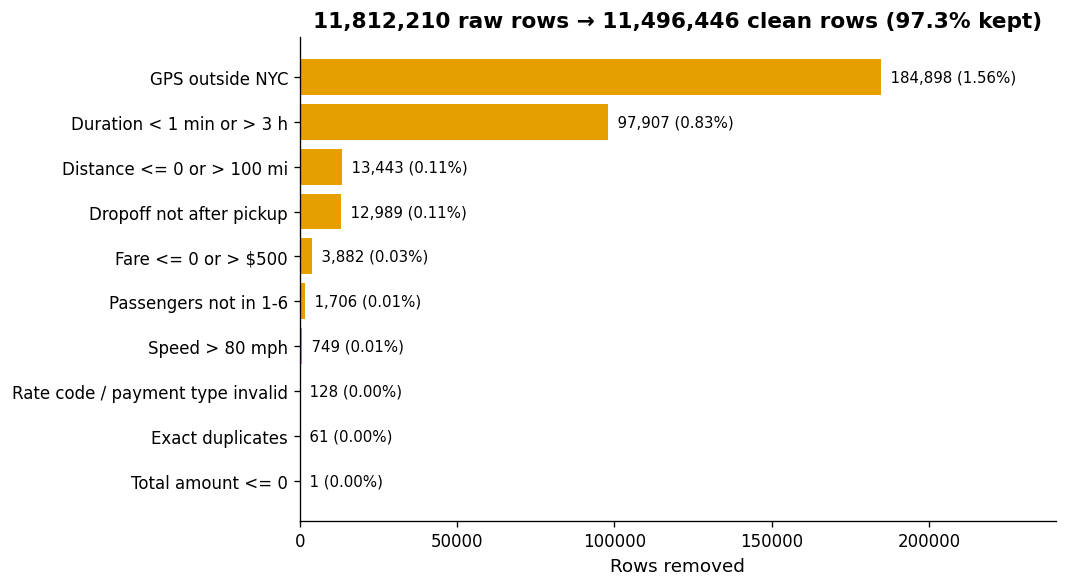

In [11]:
steps = funnel_df[funnel_df["rows_removed"] > 0].sort_values("rows_removed")
fig, ax = plt.subplots(figsize=(9, 5))
if len(steps):
    bars = ax.barh(steps["step"], steps["rows_removed"], color=ORANGE)
    for b, v, p in zip(bars, steps["rows_removed"], steps["pct_of_raw"]):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f"  {v:,} ({p:.2f}%)", va="center", fontsize=9)
    ax.set_xlim(0, steps["rows_removed"].max() * 1.3)
ax.set_xlabel("Rows removed")
ax.set_title(f"{rows_raw:,} raw rows \u2192 {rows_clean:,} clean rows ({rows_clean / rows_raw:.1%} kept)")
plt.tight_layout(); plt.savefig(FIG_DIR / "cleaning_01_row_funnel.png", dpi=200); plt.show()

### Figure 2: Missing values vs invalid values, before and after

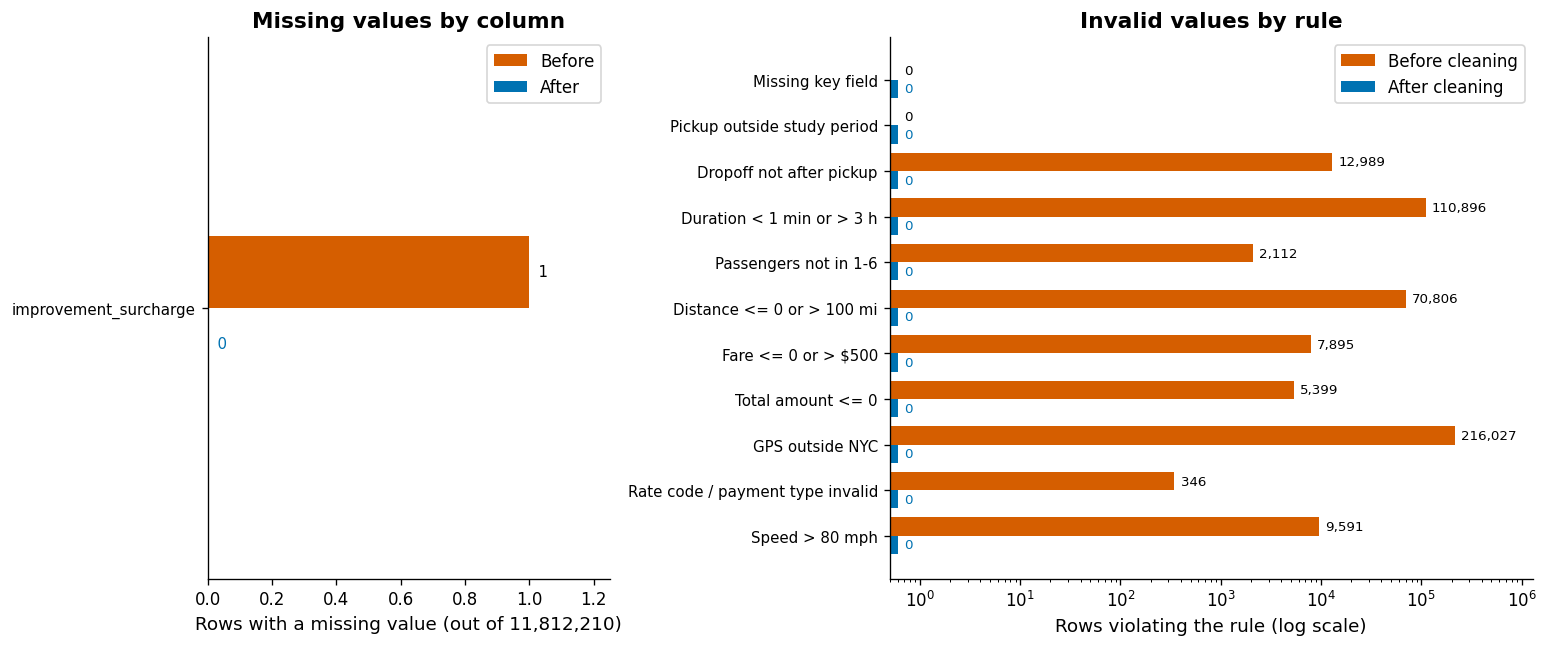

In [12]:
missing_after = to_pd(clean.isna().sum())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1, 1.6]})

# left: missing values (all columns)
m_b = missing_before[missing_before > 0]
if len(m_b):
    yy = np.arange(len(m_b))
    m_a = missing_after.reindex(m_b.index).fillna(0)
    a1.barh(yy + 0.2, m_b.values, height=0.4, color=RED, label="Before")
    a1.barh(yy - 0.2, np.maximum(m_a.values, 0), height=0.4, color=BLUE, label="After")
    for yi, bv, av in zip(yy, m_b.values, m_a.values):
        a1.text(bv, yi + 0.2, f"  {int(bv):,}", va="center", fontsize=9)
        a1.text(av, yi - 0.2, f"  {int(av):,}", va="center", fontsize=9, color=BLUE)
    a1.set_yticks(yy); a1.set_yticklabels(m_b.index, fontsize=9)
    a1.set_ylim(-1.5, len(m_b) + 0.5); a1.set_xlim(0, max(m_b.values.max() * 1.25, 1))
    a1.set_xlabel(f"Rows with a missing value (out of {rows_raw:,})"); a1.legend(loc="upper right")
    a1.set_title("Missing values by column")
else:
    a1.text(0.5, 0.5, "No missing values\nin any column\n\nThe problem is invalid values,\nnot missing ones",
            ha="center", va="center", fontsize=12, transform=a1.transAxes)
    a1.set_xticks([]); a1.set_yticks([])
    a1.set_title("Missing values (raw data)")

# right: rows violating each rule, before vs after
names = list(rule_counts_before)
y = np.arange(len(names))
b_vals = [rule_counts_before[n] for n in names]; a_vals = [rule_counts_after[n] for n in names]
a2.barh(y - 0.2, b_vals, height=0.4, color=RED, label="Before cleaning")
a2.barh(y + 0.2, [max(v, 0.6) for v in a_vals], height=0.4, color=BLUE, label="After cleaning")
for yi, bv, av in zip(y, b_vals, a_vals):
    a2.text(max(bv, 0.6) * 1.15, yi - 0.2, f"{bv:,}", va="center", fontsize=8)
    a2.text(max(av, 0.6) * 1.15, yi + 0.2, f"{av:,}", va="center", fontsize=8, color=BLUE)
a2.set_yticks(y); a2.set_yticklabels(names, fontsize=9); a2.invert_yaxis()
a2.set_xscale("log"); a2.set_xlim(0.5, max(b_vals + [10]) * 6)
a2.set_xlabel("Rows violating the rule (log scale)")
a2.set_title("Invalid values by rule"); a2.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIG_DIR / "cleaning_02_missing_vs_invalid.png", dpi=200); plt.show()

### Figure 3: Outliers before vs after (distance, fare, duration)

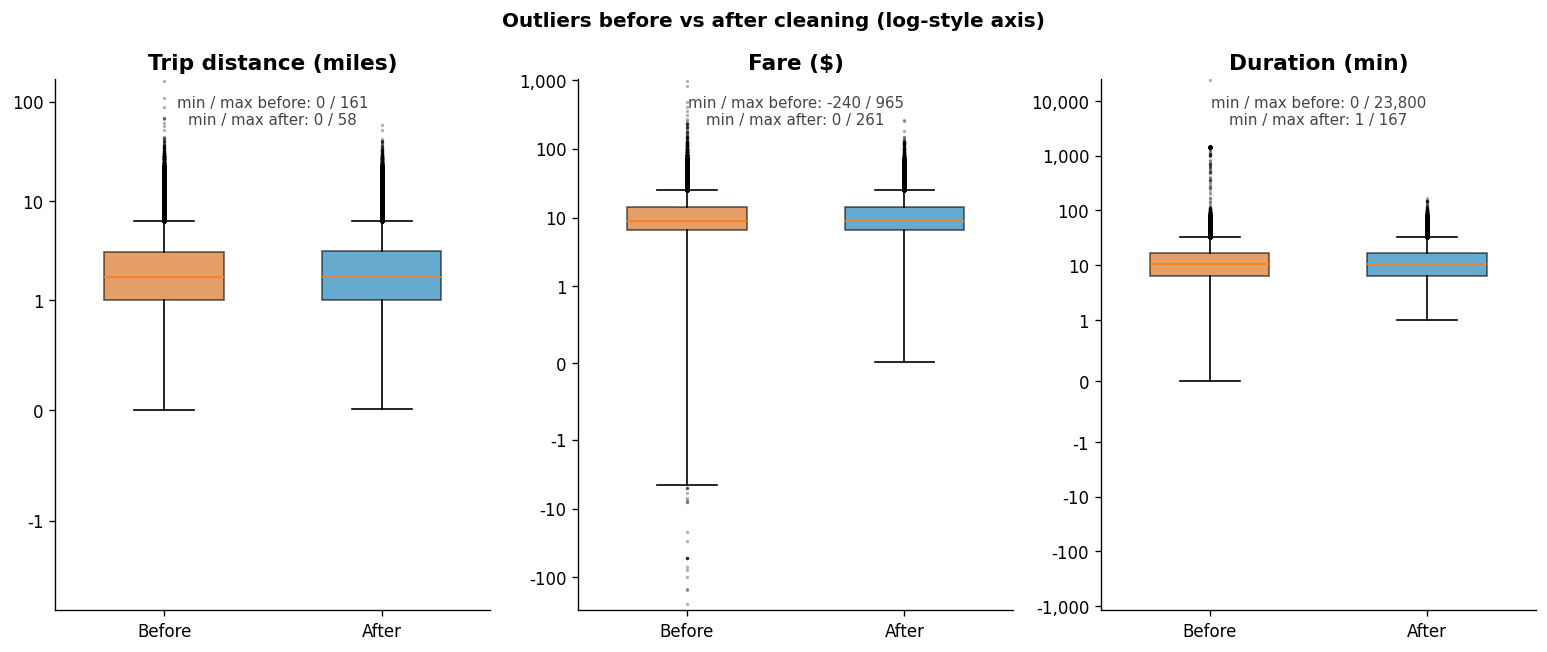

In [13]:
from matplotlib.ticker import FuncFormatter
panels = [("trip_distance", "Trip distance (miles)"), ("fare_amount", "Fare ($)"), ("duration_min", "Duration (min)")]
fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
for ax, (col, label) in zip(axes, panels):
    b = raw_sample[col].dropna(); a = clean_sample[col].dropna()
    bp = ax.boxplot([b, a], patch_artist=True, showfliers=True,
                    flierprops=dict(marker=".", markersize=2, alpha=0.3), widths=0.55)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Before", "After"])
    for patch, c in zip(bp["boxes"], [RED, BLUE]):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_yscale("symlog", linthresh=1)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_title(label)
    ax.text(0.5, 0.97, f"min / max before: {b.min():,.0f} / {b.max():,.0f}\nmin / max after: {a.min():,.0f} / {a.max():,.0f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=9, color="#444")
fig.suptitle("Outliers before vs after cleaning (log-style axis)", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR / "cleaning_03_outliers_before_after.png", dpi=200); plt.show()

### Figure 4: GPS pickup points before vs after

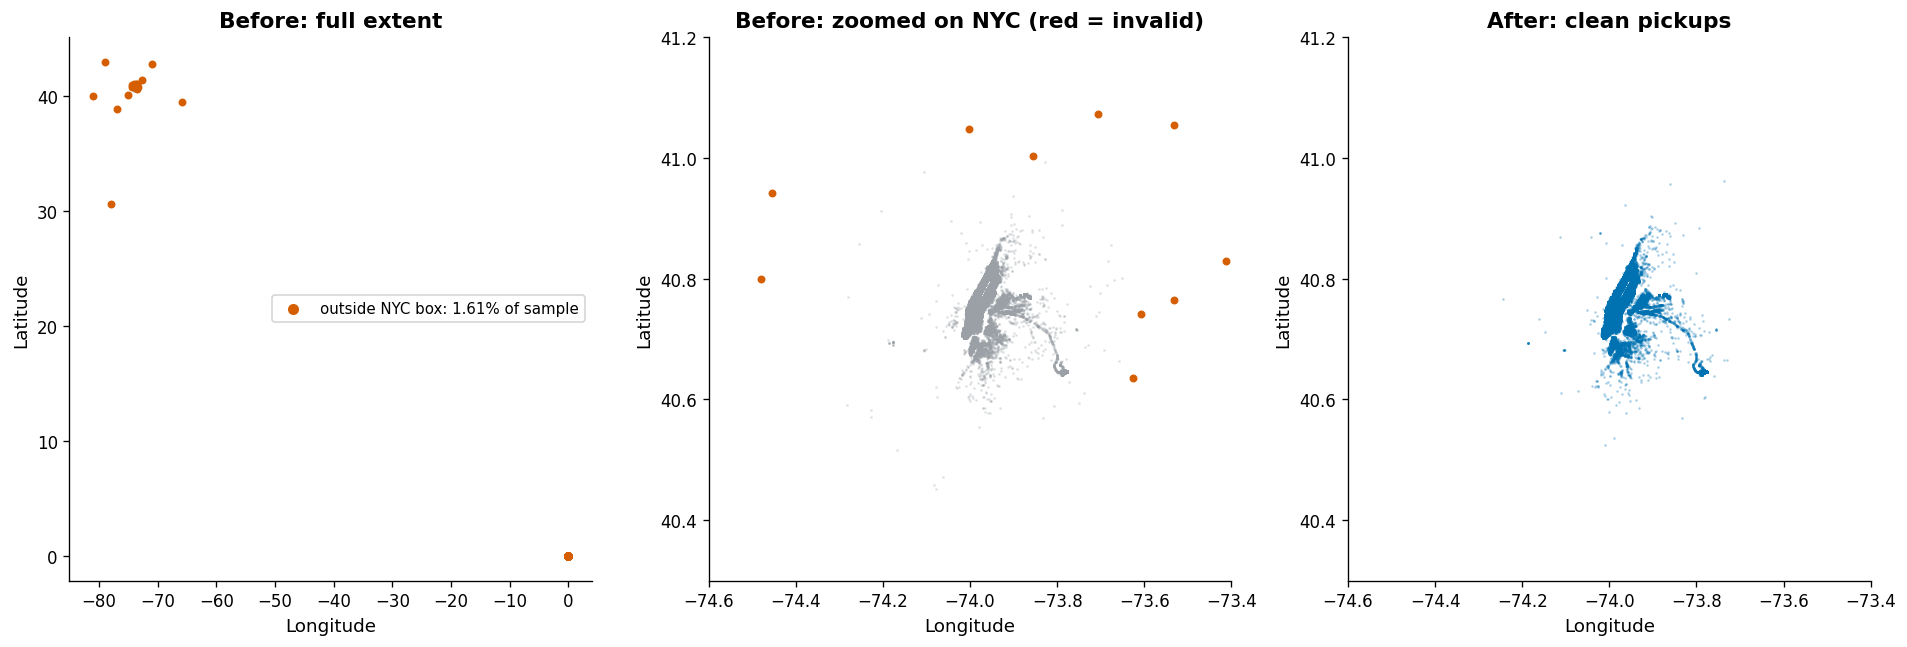

In [14]:
inside = raw_sample["pickup_latitude"].between(*NYC_LAT) & raw_sample["pickup_longitude"].between(*NYC_LON)
ZOOM_LON, ZOOM_LAT = (-74.6, -73.4), (40.3, 41.2)       # a bit wider than the NYC box so nearby bad points show

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
a1, a2, a3 = axes
for ax in (a1, a2):
    ax.scatter(raw_sample.loc[inside, "pickup_longitude"], raw_sample.loc[inside, "pickup_latitude"], s=0.3, alpha=0.3, c=GREY)
    ax.scatter(raw_sample.loc[~inside, "pickup_longitude"], raw_sample.loc[~inside, "pickup_latitude"], s=14, c=RED,
               label=f"outside NYC box: {(~inside).mean():.2%} of sample")
a1.set_title("Before: full extent"); a1.legend(loc="center right", fontsize=9, markerscale=1.5)
a2.set_xlim(ZOOM_LON); a2.set_ylim(ZOOM_LAT); a2.set_title("Before: zoomed on NYC (red = invalid)")
a3.scatter(clean_sample["pickup_longitude"], clean_sample["pickup_latitude"], s=0.3, alpha=0.3, c=BLUE)
a3.set_xlim(ZOOM_LON); a3.set_ylim(ZOOM_LAT); a3.set_title("After: clean pickups")
for ax in axes:
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.savefig(FIG_DIR / "cleaning_04_gps_before_after.png", dpi=200); plt.show()

### Figure 5: Passenger count before vs after

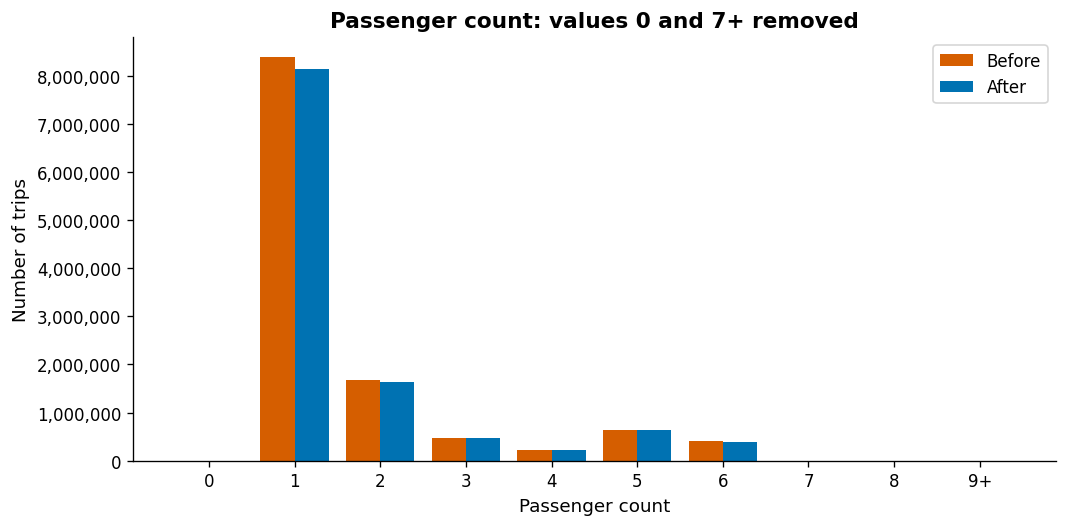

In [15]:
def bucket(s):
    s = s.dropna(); s.index = s.index.astype(int)
    out = s.groupby(np.minimum(s.index, 9)).sum()
    return out.reindex(range(0, 10), fill_value=0)

pb = bucket(passengers_before)
pa = bucket(to_pd(clean["passenger_count"].value_counts()))
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(10)
ax.bar(x - 0.2, pb.values, width=0.4, color=RED, label="Before")
ax.bar(x + 0.2, pa.values, width=0.4, color=BLUE, label="After")
ax.set_xticks(x); ax.set_xticklabels([str(i) if i < 9 else "9+" for i in x])
ax.set_xlabel("Passenger count"); ax.set_ylabel("Number of trips"); ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Passenger count: values 0 and 7+ removed")
plt.tight_layout(); plt.savefig(FIG_DIR / "cleaning_05_passenger_count.png", dpi=200); plt.show()

## 10. Save the processed dataset and the numbers for the slides

In [16]:
out_path = PROC_DIR / "yellow_taxi_clean.parquet"
try:
    clean.to_parquet(out_path)
except Exception as e:                     # e.g. pyarrow missing
    out_path = PROC_DIR / "yellow_taxi_clean.csv.gz"
    to_pd(clean).to_csv(out_path, index=False, compression="gzip")
    print("Parquet failed (", e, "), saved CSV instead")

# Small sample that CAN be committed to GitHub (the full file is too large; see .gitignore)
clean_sample.head(50_000).to_csv(PROC_DIR / "yellow_taxi_clean_sample.csv", index=False)

summary = {
    "backend": BACKEND,
    "keep_fraction": KEEP_FRACTION,
    "source_rows_total": sum(source_rows.values()),
    "source_rows_per_file": source_rows,
    "source_files": [f.name for f in files],
    "rows_raw": rows_raw, "rows_clean": rows_clean,
    "pct_retained": round(rows_clean / rows_raw * 100, 3),
    "columns_raw": len(WANTED), "columns_clean": int(clean.shape[1]),
    "funnel": [{"step": s, "rows_removed": int(n)} for s, n in funnel],
    "rule_counts_before": rule_counts_before,
    "schema_notes": schema_notes,
    "runtime_sec": round(time.time() - T0, 1),
}
(PROC_DIR / "cleaning_summary.json").write_text(json.dumps(summary, indent=2))
print("Saved:", out_path.name, "| clean sample CSV | cleaning_summary.json")
print(f"Total runtime: {summary['runtime_sec']} s on {BACKEND}")

Saved: yellow_taxi_clean.parquet | clean sample CSV | cleaning_summary.json
Total runtime: 482.8 s on pandas (CPU)


## 11. Copy-paste table for `challenges.md`, `README.md` and the slides

In [17]:
lines = ["| Step | Rows removed | % of raw |", "|---|---:|---:|"]
for s, n in funnel:
    lines.append(f"| {s} | {n:,} | {n / rows_raw:.3%} |")
lines.append(f"| **Clean rows kept** | **{rows_clean:,}** | **{rows_clean / rows_raw:.2%}** |")
print("\n".join(lines))

| Step | Rows removed | % of raw |
|---|---:|---:|
| Exact duplicates | 61 | 0.001% |
| Missing key field | 0 | 0.000% |
| Pickup outside study period | 0 | 0.000% |
| Dropoff not after pickup | 12,989 | 0.110% |
| Duration < 1 min or > 3 h | 97,907 | 0.829% |
| Passengers not in 1-6 | 1,706 | 0.014% |
| Distance <= 0 or > 100 mi | 13,443 | 0.114% |
| Fare <= 0 or > $500 | 3,882 | 0.033% |
| Total amount <= 0 | 1 | 0.000% |
| GPS outside NYC | 184,898 | 1.565% |
| Rate code / payment type invalid | 128 | 0.001% |
| Speed > 80 mph | 749 | 0.006% |
| **Clean rows kept** | **11,496,446** | **97.33%** |
